<a href="https://colab.research.google.com/github/AnkushSharmaGuragai/AI-ML/blob/main/worksheet_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check GPU
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     UpSampling2D, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


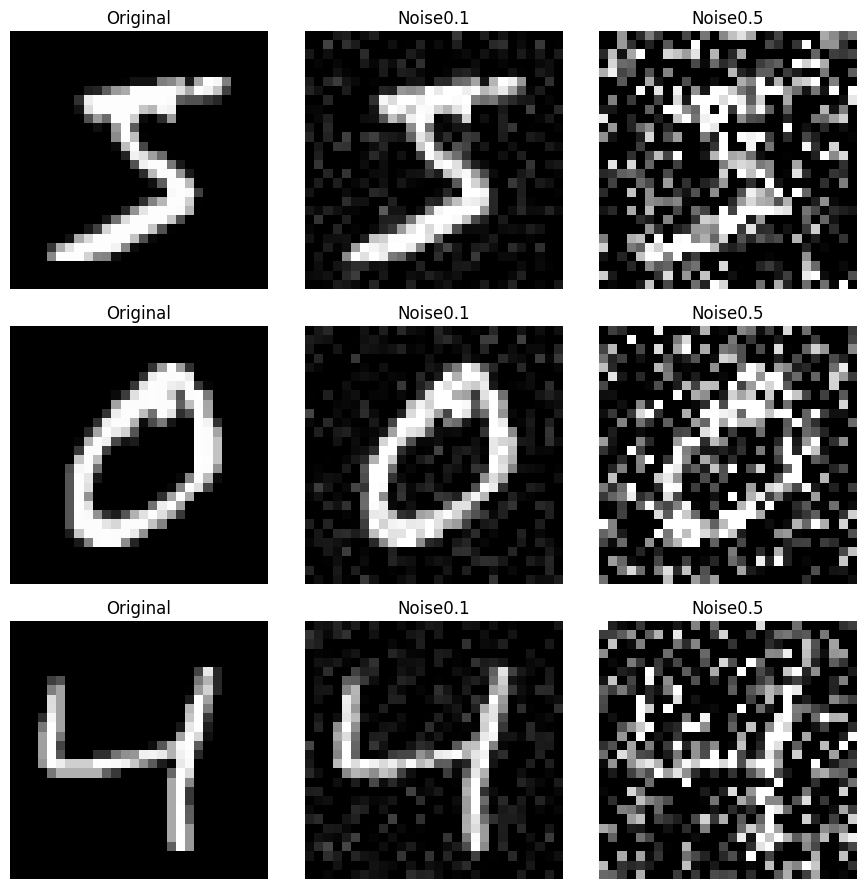

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low =np.clip(x_test_noisy_low,0.,1.)
x_train_noisy_high=np.clip(x_train_noisy_high,0.,1.)
x_test_noisy_high =np.clip(x_test_noisy_high,0.,1.)
#Visualizeina 3 x3grid
n=3 #numberof imagestoshow
plt.figure(figsize=(9,9))
for i in range(n):
    # Originalimage
    ax=plt.subplot(n,3,i*3+1)
    plt.imshow(x_train[i].reshape(28,28),cmap='gray')
    plt.title("Original")
    plt.axis('off')
    # Lownoiseimage
    ax=plt.subplot(n,3,i*3+2)
    plt.imshow(x_train_noisy_low[i].reshape(28,28),cmap='gray')
    plt.title("Noise0.1")
    plt.axis('off')
    # Highnoiseimage
    ax=plt.subplot(n,3,i*3+3)
    plt.imshow(x_train_noisy_high[i].reshape(28,28),cmap='gray')
    plt.title("Noise0.5")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Encoder
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.

    Parameters:
        input_shape (tuple): Shape of input image.

    Returns:
        input_img: Input layer
        encoded: Encoded output
    """
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)

    return input_img, encoded


# Decoder
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.

    Parameters:
        encoded_input: Output from encoder

    Returns:
        decoded: Reconstructed image
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)

    return decoded


# Full Autoencoder
def build_autoencoder(input_shape=(28, 28, 1)):
    """
    Builds and compiles the full autoencoder model.
    """
    input_img, encoded_output = build_encoder(input_shape)
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

    return autoencoder


# Build and show summary
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.1575 - val_loss: 0.1123
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.1098 - val_loss: 0.1058
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1049 - val_loss: 0.1022
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1021 - val_loss: 0.1005
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1002 - val_loss: 0.0992
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0990 - val_loss: 0.0983
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0980 - val_loss: 0.0967
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0971 - val_loss: 0.0962
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0965 - val_loss: 0.0957
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0960 - val_loss: 0.0952


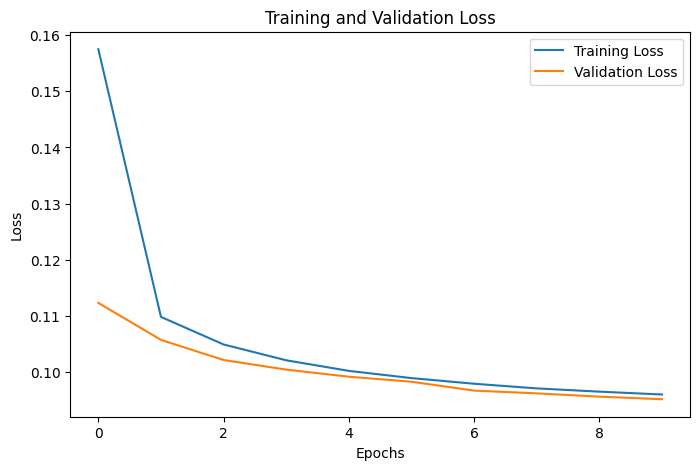

In [ ]:
import matplotlib.pyplot as plt

# Step 3: Train the Autoencoder
autoencoder = build_autoencoder()

history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


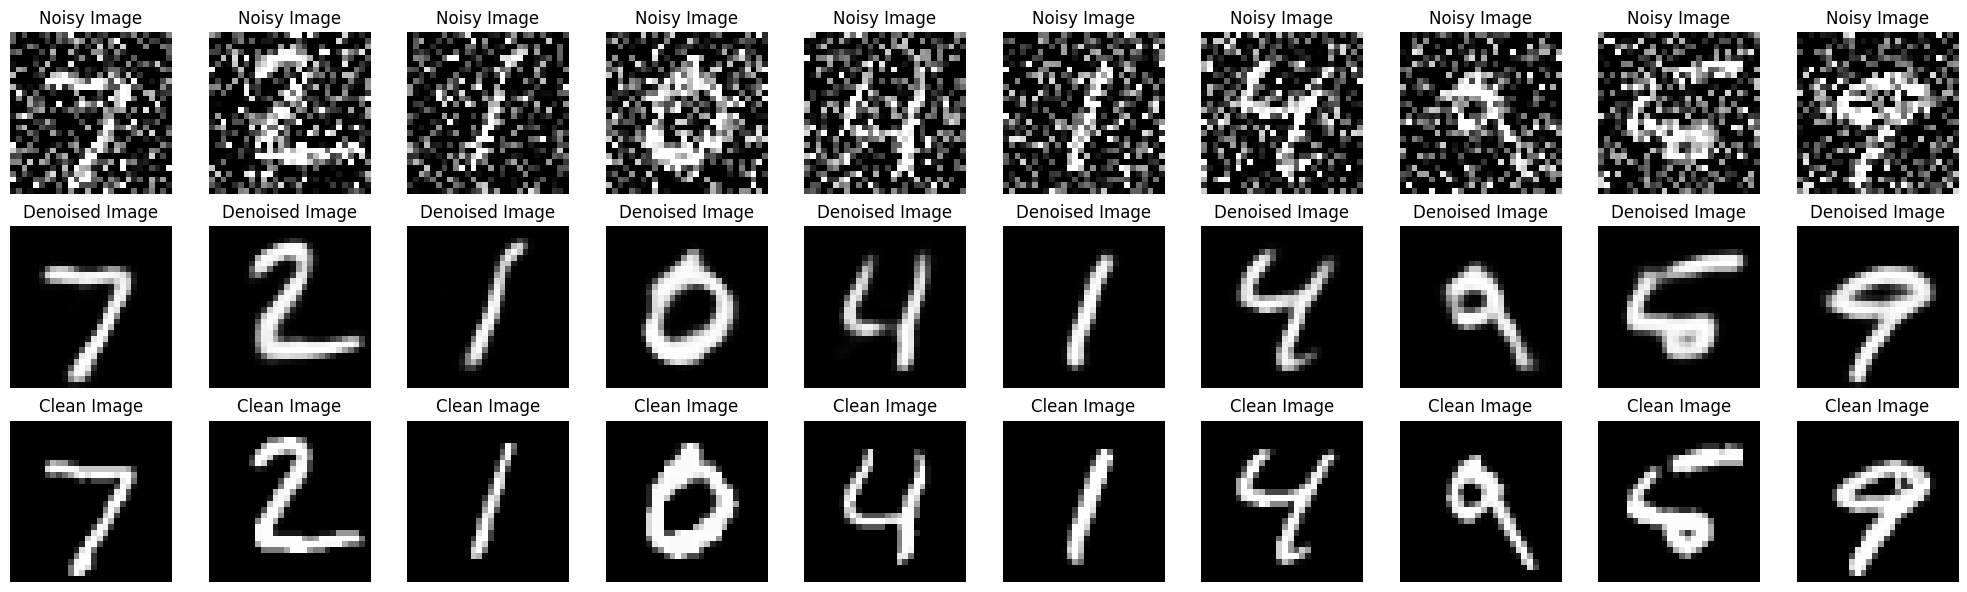

In [ ]:
# Step 4: Evaluate the Autoencoder
denoised_images = autoencoder.predict(x_test_noisy_high)

def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy image
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Denoised image
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Clean image
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

In [ ]:
dataset_path = "/content/drive/MyDrive/AI ML/DevanagariHandwrittenDigitDataset/Train"
img_size = 32

In [ ]:
def load_devnagari_images(data_dir, img_size=32):
    images = []
    labels = []

    class_names = sorted(os.listdir(data_dir))

    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            try:
                img = Image.open(file_path).convert("L")   # grayscale
                img = img.resize((img_size, img_size))
                img = np.array(img, dtype=np.float32) / 255.0   # normalize to [0,1]
                images.append(img)
                labels.append(class_name)
            except Exception as e:
                print(f"Skipping {file_path}: {e}")

    images = np.array(images)
    labels = np.array(labels)

    return images, labels


images, labels = load_devnagari_images(dataset_path, img_size=img_size)

print("Images shape before channel dimension:", images.shape)
print("Labels shape:", labels.shape)

Images shape before channel dimension: (17000, 32, 32)
Labels shape: (17000,)


In [ ]:
images = np.expand_dims(images, axis=-1)
print("Images shape after channel dimension:", images.shape)

Images shape after channel dimension: (17000, 32, 32, 1)


In [ ]:
x_train, x_val = train_test_split(images, test_size=0.2, random_state=42, shuffle=True)

print("Training shape:", x_train.shape)
print("Validation shape:", x_val.shape)

Training shape: (13600, 32, 32, 1)
Validation shape: (3400, 32, 32, 1)


In [ ]:
noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_val_noisy   = x_val   + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_val.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy   = np.clip(x_val_noisy, 0., 1.)

print("Noisy train shape:", x_train_noisy.shape)
print("Noisy val shape:", x_val_noisy.shape)

Noisy train shape: (13600, 32, 32, 1)
Noisy val shape: (3400, 32, 32, 1)


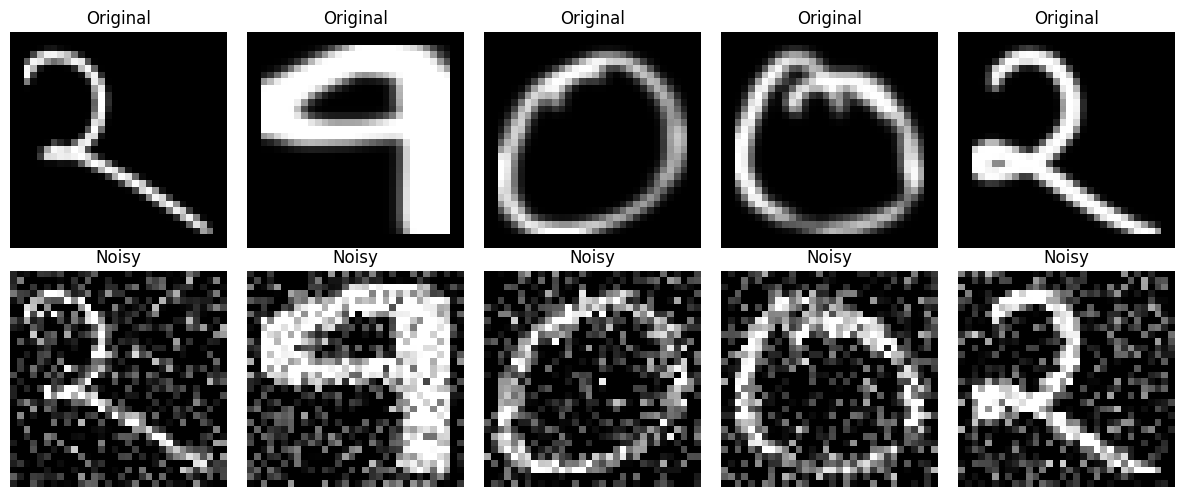

In [ ]:
n = 5
plt.figure(figsize=(12, 5))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def build_denoising_autoencoder(input_shape=(32, 32, 1)):
    input_img = Input(shape=input_shape, name="input")

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)

    # Decoder
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)

    model = Model(inputs=input_img, outputs=decoded, name="devnagari_denoising_autoencoder")
    model.compile(optimizer=Adam(), loss='binary_crossentropy')

    return model


autoencoder = build_denoising_autoencoder(input_shape=(img_size, img_size, 1))
autoencoder.summary()

Model: "devnagari_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 0.3687 - val_loss: 0.2298
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2044 - val_loss: 0.1860
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1757 - val_loss: 0.1681
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1618 - val_loss: 0.1618
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1545 - val_loss: 0.1527
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1480 - val_loss: 0.1486
Epoch 7/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1442 - val_loss: 0.1447
Epoch 8/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1413 - val_loss: 0.1415
Epoch 9/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1396 - val_loss: 0.1397
Epoch 10/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1376 - val_loss: 0.1386
Epoch 11/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1364 - val_loss: 0.1380
Epoch 12/15
107/107 ━━━━━━━━━━━━━━━━━━━━

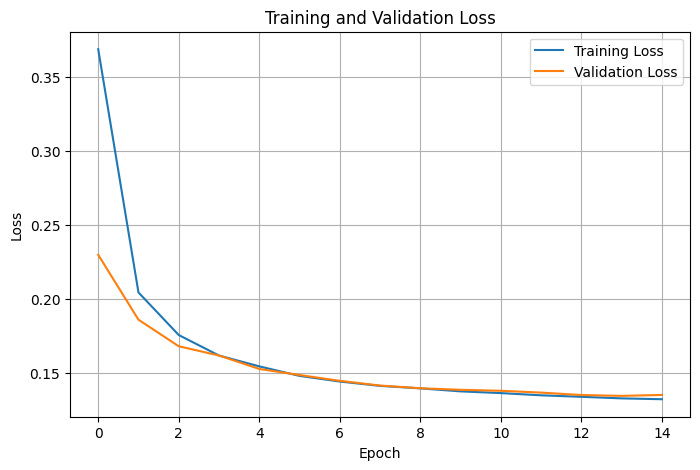

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
denoised_images = autoencoder.predict(x_val_noisy)
print("Denoised images shape:", denoised_images.shape)

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Denoised images shape: (3400, 32, 32, 1)


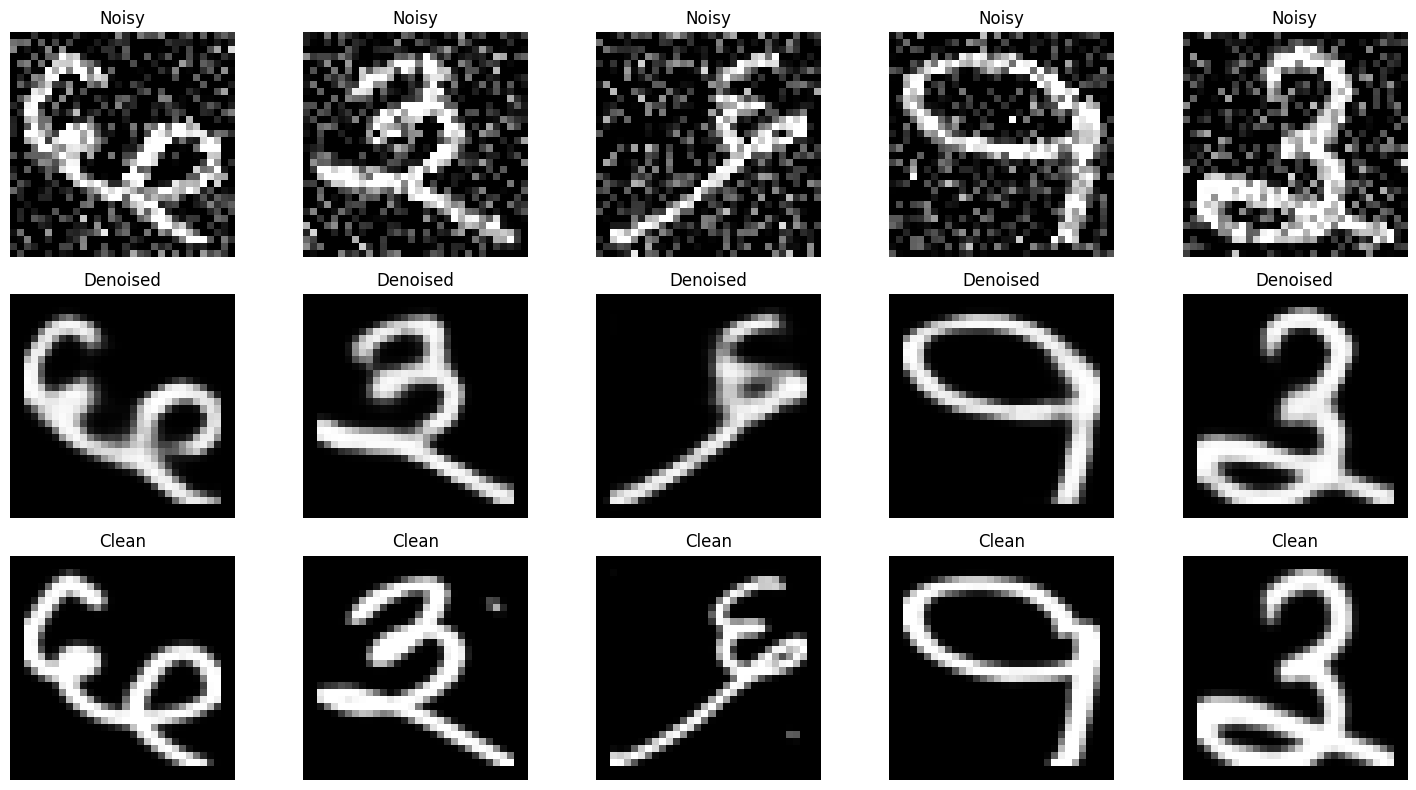

In [ ]:
def plot_denoising_results(noisy_images, denoised_images, clean_images, n=5):
    plt.figure(figsize=(15, 8))

    for i in range(n):
        # Noisy
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(img_size, img_size), cmap='gray')
        plt.title("Noisy")
        plt.axis("off")

        # Denoised
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(img_size, img_size), cmap='gray')
        plt.title("Denoised")
        plt.axis("off")

        # Clean
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(img_size, img_size), cmap='gray')
        plt.title("Clean")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


plot_denoising_results(x_val_noisy, denoised_images, x_val, n=5)

In [ ]:
autoencoder.save("devnagari_denoising_autoencoder.h5")
print("Model saved successfully.")

Model saved successfully.
